In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

In [2]:
model_dir = Path("../ml_models")
test_data_dir = Path("../data/model_input")

best_model = joblib.load(model_dir / "best_loan_model.pkl")
scaler = joblib.load(model_dir / "scaler.pkl")
best_model_name = joblib.load(model_dir / "best_model_name.pkl")

X_test = pd.read_csv(test_data_dir / "X_test.csv")
y_test = pd.read_csv(test_data_dir / "y_test.csv").squeeze()

best_model_name

'Decision Tree'

In [3]:
X_test_input = scaler.transform(X_test) if best_model_name == "Logistic Regression" else X_test

y_pred = best_model.predict(X_test_input)
y_prob = best_model.predict_proba(X_test_input)[:, 1]

In [4]:
final_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1_score": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_prob),
}

final_metrics

{'accuracy': 0.9988290398126464,
 'precision': 0.9981203007518797,
 'recall': 1.0,
 'f1_score': 0.9990592662276576,
 'roc_auc': 0.9984520123839009}

In [5]:
print(classification_report(y_test, y_pred, target_names=["Rejected", "Approved"]))

              precision    recall  f1-score   support

    Rejected       1.00      1.00      1.00       323
    Approved       1.00      1.00      1.00       531

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854



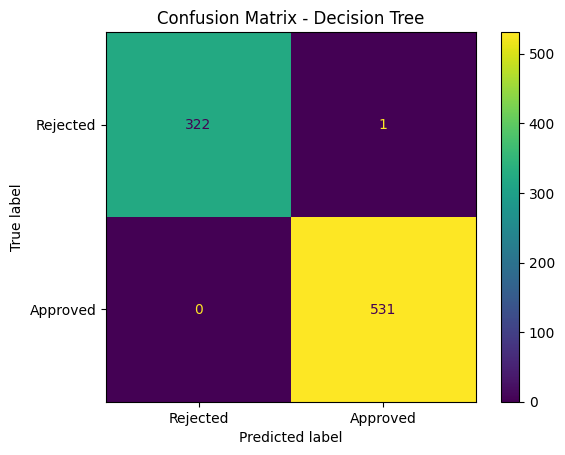

In [6]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Rejected", "Approved"])

plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

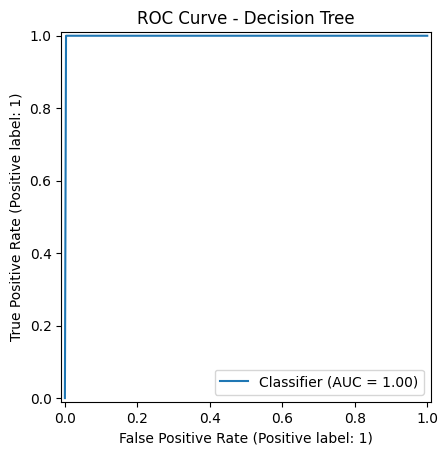

In [7]:
RocCurveDisplay.from_predictions(y_test, y_prob)

plt.title(f"ROC Curve - {best_model_name}")
plt.show()

In [8]:
if hasattr(best_model, "feature_importances_"):
    feature_importance_df = pd.DataFrame(
        {"feature": X_test.columns, "importance": best_model.feature_importances_}
    ).sort_values(by="importance", ascending=False)

elif hasattr(best_model, "coef_"):
    feature_importance_df = pd.DataFrame({"feature": X_test.columns, "importance": best_model.coef_[0]}).sort_values(
        by="importance", ascending=False
    )

feature_importance_df

,feature,importance
6,cibil_score,0.810427
11,loan_income_ratio,0.090911
5,loan_term,0.083806
14,net_worth,0.014856
1,education,0.000000
2,self_employed,0.000000
0,no_of_dependents,0.000000
3,income_annum,0.000000
4,loan_amount,0.000000
7,residential_assets_value,0.000000


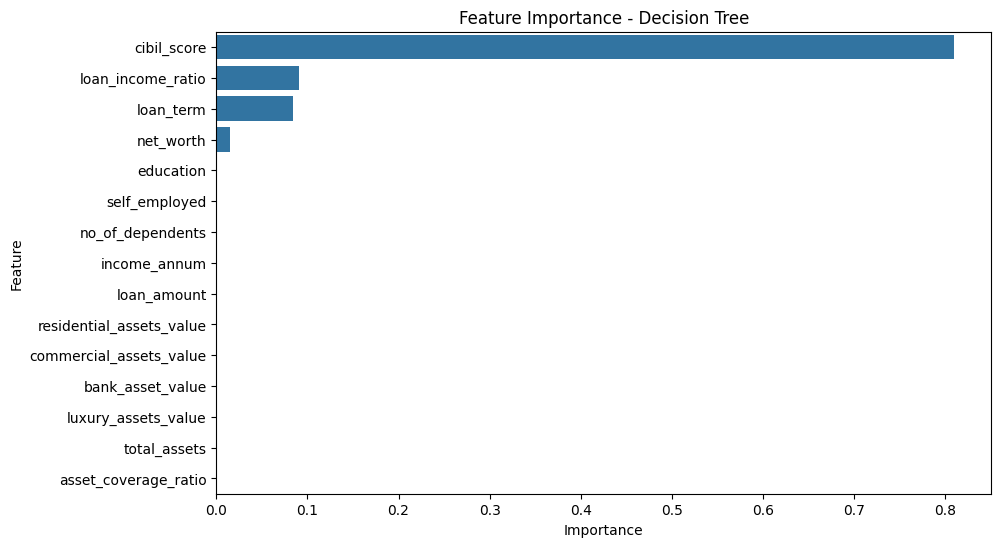

In [9]:
plt.figure(figsize=(10, 6))

sns.barplot(data=feature_importance_df, x="importance", y="feature")

plt.title(f"Feature Importance - {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [10]:
error_df = X_test.copy()
error_df["actual"] = y_test.values
error_df["predicted"] = y_pred
error_df["prediction_probability"] = y_prob

wrong_predictions = error_df[error_df["actual"] != error_df["predicted"]]

wrong_predictions.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_income_ratio,total_assets,asset_coverage_ratio,net_worth,actual,predicted,prediction_probability
638,5,0,0,600000,2300000,4,347,0,0,1900000,200000,3.833333,2100000,0.913043,-200000,0,1,1.0


In [11]:
wrong_predictions.shape

(1, 18)

## Model Evaluation Summary

The selected model was evaluated on the holdout test dataset using accuracy, precision, recall, F1-score, ROC-AUC, confusion matrix, ROC curve, feature importance, and error analysis.

The model achieved very strong performance on unseen test data. Feature importance confirms that `cibil_score` is the dominant predictor of loan approval, which aligns with the EDA findings.

The error analysis was used to inspect misclassified records and understand where the model made incorrect predictions.